# 🚀 Vision Transformer для классификации изображений

## Описание
Этот notebook реализует Vision Transformer (ViT) с механизмом self-attention для классификации радиолокационных изображений.

### Основные возможности:
- ✅ Vision Transformer архитектура с self-attention
- ✅ Fine-tuning предобученной модели
- ✅ Data Augmentation для улучшения обобщения
- ✅ Early Stopping и Learning Rate Scheduler
- ✅ Визуализация метрик и attention maps
- ✅ Поддержка 6 классов радиолокационных изображений

### Структура датасета:
```
dataset/
  class_0/
    image1.jpg
    image2.jpg
  class_1/
    image1.jpg
  ...
  class_5/
```

## 📦 Установка необходимых библиотек

In [1]:
# Установка библиотек (запустите один раз)
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install transformers datasets pillow matplotlib seaborn scikit-learn
!pip install timm  # PyTorch Image Models - для предобученных Vision Transformers

Looking in indexes: https://download.pytorch.org/whl/cu118


## 📚 Импорт библиотек

In [2]:
# Основные библиотеки
import os
import numpy as np
import pandas as pd
from pathlib import Path
import random
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

# Torchvision для работы с изображениями
import torchvision
from torchvision import transforms
from torchvision.datasets import ImageFolder
from PIL import Image

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

# Метрики
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Transformers от HuggingFace
from transformers import ViTImageProcessor, ViTForImageClassification, ViTConfig
import timm

# Google Drive монтирование
from google.colab import drive

print("✅ Все библиотеки успешно импортированы!")
print(f"🔥 PyTorch версия: {torch.__version__}")
print(f"🎮 CUDA доступна: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"🎯 GPU: {torch.cuda.get_device_name(0)}")

✅ Все библиотеки успешно импортированы!
🔥 PyTorch версия: 2.9.0+cu126
🎮 CUDA доступна: True
🎯 GPU: Tesla T4


## ⚙️ Настройка параметров и воспроизводимости

In [3]:
# Установка seed для воспроизводимости результатов
def set_seed(seed=42):
    """Фиксируем random seed для воспроизводимости экспериментов"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Для полной детерминированности (может замедлить обучение)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Устройство для вычислений (GPU если доступен, иначе CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Используем устройство: {device}")

🖥️  Используем устройство: cuda


## 🔧 Конфигурация модели и обучения

In [4]:
class Config:
    """Класс с конфигурацией параметров модели и обучения"""

    # === Параметры датасета ===
    NUM_CLASSES = 6  # Количество классов радиолокационных изображений
    IMAGE_SIZE = 224  # Размер изображения (ViT обычно использует 224x224)

    # === Параметры разделения данных ===
    TRAIN_RATIO = 0.7  # 70% данных для обучения
    VAL_RATIO = 0.15   # 15% данных для валидации
    TEST_RATIO = 0.15  # 15% данных для тестирования

    # === Параметры обучения ===
    BATCH_SIZE = 16  # Размер батча (уменьшите если не хватает памяти GPU)
    NUM_EPOCHS = 50  # Максимальное количество эпох
    LEARNING_RATE = 3e-4  # Начальная скорость обучения
    WEIGHT_DECAY = 0.01  # L2 регуляризация

    # === Early Stopping ===
    PATIENCE = 10  # Количество эпох без улучшения до остановки
    MIN_DELTA = 0.001  # Минимальное улучшение для учета

    # === Модель ===
    MODEL_NAME = 'google/vit-base-patch16-224'  # Предобученная ViT модель
    # Альтернативы:
    # 'google/vit-base-patch16-224-in21k' - больше параметров
    # 'google/vit-large-patch16-224' - еще больше (требует больше памяти)

    # === Пути ===
    DRIVE_MOUNT_PATH = '/content/drive'  # Путь монтирования Google Drive
    DATASET_PATH = ''  # Будет установлен после монтирования Drive
    SAVE_MODEL_PATH = '/content/best_model.pth'  # Путь для сохранения лучшей модели

    # === Дополнительные параметры ===
    NUM_WORKERS = 2  # Количество потоков для загрузки данных

config = Config()
print("✅ Конфигурация создана")
print(f"📊 Классов: {config.NUM_CLASSES}")
print(f"🖼️  Размер изображений: {config.IMAGE_SIZE}x{config.IMAGE_SIZE}")
print(f"🎯 Batch size: {config.BATCH_SIZE}")

✅ Конфигурация создана
📊 Классов: 6
🖼️  Размер изображений: 224x224
🎯 Batch size: 16


## 💾 Подключение Google Drive и загрузка датасета

In [5]:
# Монтирование Google Drive
drive.mount(config.DRIVE_MOUNT_PATH)
print("✅ Google Drive успешно подключен!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive успешно подключен!


In [6]:
# ВАЖНО: Укажите путь к вашему датасету на Google Drive
# Например: '/content/drive/MyDrive/radar_dataset'
config.DATASET_PATH = '/content/drive/MyDrive/dataset_nik'  # ← ИЗМЕНИТЕ НА СВОЙ ПУТЬ

# Проверка существования датасета
if not os.path.exists(config.DATASET_PATH):
    print("❌ ОШИБКА: Датасет не найден!")
    print(f"📁 Путь: {config.DATASET_PATH}")
    print("\n💡 Инструкция:")
    print("1. Загрузите датасет на Google Drive")
    print("2. Организуйте его в структуру:")
    print("   dataset/")
    print("     class_0/")
    print("       image1.jpg")
    print("       image2.jpg")
    print("     class_1/")
    print("       ...")
    print("     ...")
    print("     class_5/")
    print("3. Обновите переменную DATASET_PATH выше")
else:
    print("✅ Датасет найден!")
    print(f"📁 Путь: {config.DATASET_PATH}")

    # Показываем структуру датасета
    classes = sorted([d for d in os.listdir(config.DATASET_PATH)
                     if os.path.isdir(os.path.join(config.DATASET_PATH, d))])
    print(f"\n📊 Найдено классов: {len(classes)}")

    for cls in classes:
        cls_path = os.path.join(config.DATASET_PATH, cls)
        num_images = len([f for f in os.listdir(cls_path)
                         if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))])
        print(f"  📂 {cls}: {num_images} изображений")

✅ Датасет найден!
📁 Путь: /content/drive/MyDrive/dataset_nik

📊 Найдено классов: 6
  📂 2S1: 273 изображений
  📂 BRDM_2: 273 изображений
  📂 D_7: 273 изображений
  📂 T_62: 273 изображений
  📂 ZSU_23_4: 273 изображений
  📂 ZiL_131: 273 изображений


## 🎨 Data Augmentation и трансформации

In [7]:
# Трансформации для обучающей выборки (с аугментацией)
train_transforms = transforms.Compose([
    # Изменение размера до чуть большего размера для random crop
    transforms.Resize((config.IMAGE_SIZE + 32, config.IMAGE_SIZE + 32)),

    # Случайный crop до целевого размера
    transforms.RandomCrop((config.IMAGE_SIZE, config.IMAGE_SIZE)),

    # Случайное горизонтальное отражение (50% вероятность)
    transforms.RandomHorizontalFlip(p=0.5),

    # Случайное вертикальное отражение (может быть полезно для радиолокационных изображений)
    transforms.RandomVerticalFlip(p=0.5),

    # Случайный поворот (±15 градусов)
    transforms.RandomRotation(degrees=15),

    # Случайное изменение яркости, контраста, насыщенности
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.1),

    # Конвертация в тензор
    transforms.ToTensor(),

    # Нормализация (используем статистику ImageNet)
    # Это важно для fine-tuning предобученных моделей
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # Средние значения RGB каналов ImageNet
        std=[0.229, 0.224, 0.225]    # Стандартные отклонения RGB каналов ImageNet
    )
])

# Трансформации для валидации и тестирования (без аугментации)
val_test_transforms = transforms.Compose([
    # Изменение размера
    transforms.Resize((config.IMAGE_SIZE, config.IMAGE_SIZE)),

    # Конвертация в тензор
    transforms.ToTensor(),

    # Нормализация (те же значения что и для train)
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("✅ Трансформации созданы!")
print("📈 Train: с аугментацией (flip, rotation, color jitter)")
print("📉 Val/Test: только resize и нормализация")

✅ Трансформации созданы!
📈 Train: с аугментацией (flip, rotation, color jitter)
📉 Val/Test: только resize и нормализация


## 📊 Загрузка и разделение датасета

In [8]:
# Загружаем полный датасет
full_dataset = ImageFolder(root=config.DATASET_PATH)

print(f"📊 Загружено изображений: {len(full_dataset)}")
print(f"📂 Классов: {len(full_dataset.classes)}")
print(f"🏷️  Названия классов: {full_dataset.classes}")

# Создаем словарь маппинга: индекс -> название класса
idx_to_class = {i: class_name for i, class_name in enumerate(full_dataset.classes)}
class_to_idx = full_dataset.class_to_idx

print("\n📋 Маппинг классов:")
for idx, class_name in idx_to_class.items():
    print(f"  {idx} → {class_name}")

📊 Загружено изображений: 1638
📂 Классов: 6
🏷️  Названия классов: ['2S1', 'BRDM_2', 'D_7', 'T_62', 'ZSU_23_4', 'ZiL_131']

📋 Маппинг классов:
  0 → 2S1
  1 → BRDM_2
  2 → D_7
  3 → T_62
  4 → ZSU_23_4
  5 → ZiL_131


In [9]:
# Разделение на train, validation и test
total_size = len(full_dataset)
train_size = int(config.TRAIN_RATIO * total_size)
val_size = int(config.VAL_RATIO * total_size)
test_size = total_size - train_size - val_size  # Остаток идет в test

# Случайное разделение датасета
train_dataset_raw, val_dataset_raw, test_dataset_raw = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)  # Для воспроизводимости
)

print(f"\n✂️ Разделение датасета:")
print(f"  🎯 Train: {len(train_dataset_raw)} ({config.TRAIN_RATIO*100:.0f}%)")
print(f"  ✅ Validation: {len(val_dataset_raw)} ({config.VAL_RATIO*100:.0f}%)")
print(f"  🧪 Test: {len(test_dataset_raw)} ({config.TEST_RATIO*100:.0f}%)")


✂️ Разделение датасета:
  🎯 Train: 1146 (70%)
  ✅ Validation: 245 (15%)
  🧪 Test: 247 (15%)


In [10]:
# Применяем трансформации к разделенным датасетам
# Для этого создаем wrapper класс

class TransformedSubset(Dataset):
    """Wrapper для применения трансформаций к Subset"""
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, label = self.subset[idx]

        # Если изображение уже тензор (после split), конвертируем обратно в PIL
        if isinstance(image, torch.Tensor):
            image = transforms.ToPILImage()(image)

        # Применяем трансформации
        if self.transform:
            image = self.transform(image)

        return image, label

# Создаем финальные датасеты с трансформациями
train_dataset = TransformedSubset(train_dataset_raw, transform=train_transforms)
val_dataset = TransformedSubset(val_dataset_raw, transform=val_test_transforms)
test_dataset = TransformedSubset(test_dataset_raw, transform=val_test_transforms)

print("✅ Трансформации применены к датасетам")

✅ Трансформации применены к датасетам


In [11]:
# Создание DataLoader'ов для эффективной загрузки батчей
train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,  # Перемешиваем данные каждую эпоху
    num_workers=0, # Изменено с config.NUM_WORKERS на 0 для предотвращения ошибок
    pin_memory=True if torch.cuda.is_available() else False  # Ускоряет передачу на GPU
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,  # Валидацию не перемешиваем
    num_workers=0, # Изменено с config.NUM_WORKERS на 0
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=0, # Изменено с config.NUM_WORKERS на 0
    pin_memory=True if torch.cuda.is_available() else False
)

print("✅ DataLoader'ы созданы!")
print(f"  📦 Train batches: {len(train_loader)}")
print(f"  📦 Val batches: {len(val_loader)}")
print(f"  📦 Test batches: {len(test_loader)}")

✅ DataLoader'ы созданы!
  📦 Train batches: 72
  📦 Val batches: 16
  📦 Test batches: 16


## 🔍 Визуализация примеров данных

🎨 Примеры из обучающей выборки (с аугментацией):


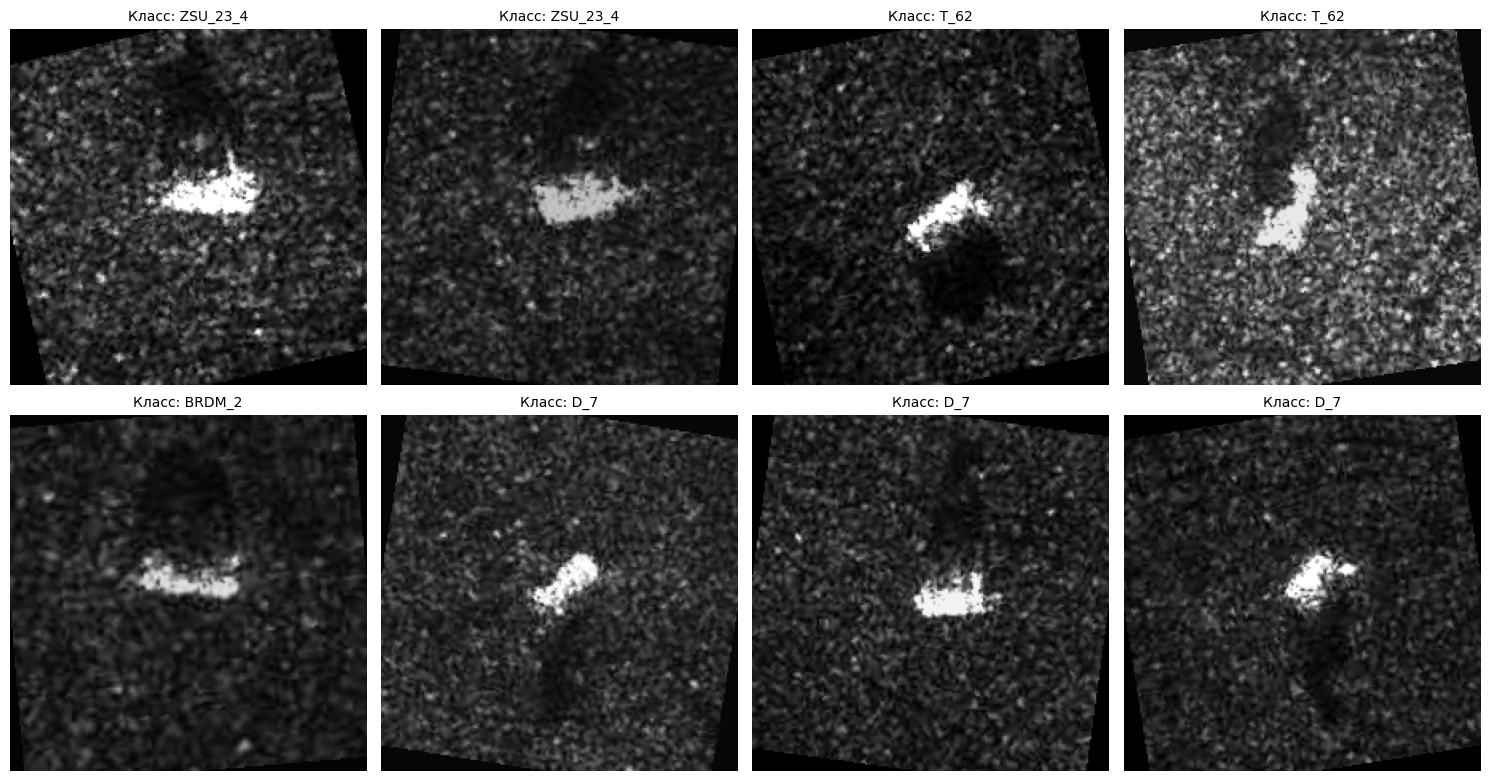

In [12]:
def show_batch(dataloader, num_images=8, denormalize=True):
    """
    Визуализация батча изображений

    Args:
        dataloader: DataLoader с изображениями
        num_images: количество изображений для показа
        denormalize: денормализовать изображения (для корректного отображения)
    """
    # Получаем один батч
    images, labels = next(iter(dataloader))

    # Берем только num_images изображений
    images = images[:num_images]
    labels = labels[:num_images]

    # Создаем сетку
    fig, axes = plt.subplots(2, 4, figsize=(15, 8))
    axes = axes.flatten()

    # Параметры для денормализации (обратная операция к Normalize)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    for idx, (image, label) in enumerate(zip(images, labels)):
        # Денормализация
        if denormalize:
            image = image * std + mean
            image = torch.clamp(image, 0, 1)  # Обрезаем значения в диапазон [0, 1]

        # Конвертируем в numpy и меняем порядок каналов (C, H, W) -> (H, W, C)
        image_np = image.permute(1, 2, 0).numpy()

        # Отображаем
        axes[idx].imshow(image_np)
        axes[idx].set_title(f'Класс: {idx_to_class[label.item()]}', fontsize=10)
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

# Показываем примеры из обучающей выборки
print("🎨 Примеры из обучающей выборки (с аугментацией):")
show_batch(train_loader, num_images=8)

## 🏗️ Создание модели Vision Transformer

In [13]:
# Загружаем предобученную Vision Transformer модель
print(f"📥 Загрузка модели: {config.MODEL_NAME}...")

# Загружаем конфигурацию для предобученной модели
vit_config = ViTConfig.from_pretrained(config.MODEL_NAME)
# Устанавливаем output_attentions в True в конфигурации
vit_config.output_attentions = True
vit_config.num_labels = config.NUM_CLASSES  # Устанавливаем количество классов

# Создаем модель с нашей модифицированной конфигурацией
model = ViTForImageClassification.from_pretrained(
    config.MODEL_NAME,
    config=vit_config,  # Передаем модифицированную конфигурацию
    ignore_mismatched_sizes=True  # Игнорируем несовпадение размеров выходного слоя
)

# Переносим модель на GPU (если доступен)
model = model.to(device)

print("✅ Модель успешно загружена!")

# Подсчет параметров модели
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n📊 Статистика модели:")
print(f"  🔢 Всего параметров: {total_params:,}")
print(f"  🎯 Обучаемых параметров: {trainable_params:,}")
print(f"  💾 Размер модели: ~{total_params * 4 / 1024 / 1024:.2f} MB")

📥 Загрузка модели: google/vit-base-patch16-224...


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([6]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([6, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Модель успешно загружена!

📊 Статистика модели:
  🔢 Всего параметров: 85,803,270
  🎯 Обучаемых параметров: 85,803,270
  💾 Размер модели: ~327.31 MB


## 🎓 Настройка оптимизатора и функции потерь

In [14]:
# Функция потерь (Cross Entropy Loss для классификации)
criterion = nn.CrossEntropyLoss()

# Оптимизатор AdamW (улучшенная версия Adam с weight decay)
optimizer = optim.AdamW(
    model.parameters(),
    lr=config.LEARNING_RATE,
    weight_decay=config.WEIGHT_DECAY
)

# Learning Rate Scheduler (уменьшает lr при plateau на валидации)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',  # Максимизируем accuracy
    factor=0.5,  # Уменьшаем lr в 2 раза
    patience=5 # После 5 эпох без улучшения
)

print("✅ Оптимизатор и scheduler созданы!")
print(f"  📉 Loss: CrossEntropyLoss")
print(f"  🎯 Optimizer: AdamW (lr={config.LEARNING_RATE}, wd={config.WEIGHT_DECAY})")
print(f"  📊 Scheduler: ReduceLROnPlateau")

✅ Оптимизатор и scheduler созданы!
  📉 Loss: CrossEntropyLoss
  🎯 Optimizer: AdamW (lr=0.0003, wd=0.01)
  📊 Scheduler: ReduceLROnPlateau


## 🚂 Функции для обучения и валидации

In [15]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """
    Обучение модели на одной эпохе

    Args:
        model: модель для обучения
        dataloader: DataLoader с обучающими данными
        criterion: функция потерь
        optimizer: оптимизатор
        device: устройство (CPU/GPU)

    Returns:
        avg_loss: средний loss за эпоху
        accuracy: точность на обучающей выборке
    """
    model.train()  # Переключаем модель в режим обучения

    running_loss = 0.0
    correct = 0
    total = 0

    # Прогресс бар
    pbar = tqdm(dataloader, desc='Training', leave=False)

    for images, labels in pbar:
        # Переносим данные на device
        images = images.to(device)
        labels = labels.to(device)

        # Обнуляем градиенты
        optimizer.zero_grad()

        # Forward pass
        outputs = model(pixel_values=images)
        logits = outputs.logits

        # Вычисляем loss
        loss = criterion(logits, labels)

        # Backward pass и оптимизация
        loss.backward()
        optimizer.step()

        # Статистика
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(logits, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # Обновляем прогресс бар
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100 * correct / total:.2f}%'
        })

    # Средние значения за эпоху
    avg_loss = running_loss / total
    accuracy = 100 * correct / total

    return avg_loss, accuracy


def validate(model, dataloader, criterion, device):
    """
    Валидация модели

    Args:
        model: модель для валидации
        dataloader: DataLoader с валидационными данными
        criterion: функция потерь
        device: устройство (CPU/GPU)

    Returns:
        avg_loss: средний loss
        accuracy: точность
        all_preds: все предсказания
        all_labels: все истинные метки
    """
    model.eval()  # Переключаем модель в режим валидации

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    # Отключаем вычисление градиентов для ускорения
    with torch.no_grad():
        pbar = tqdm(dataloader, desc='Validation', leave=False)

        for images, labels in pbar:
            # Переносим данные на device
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(pixel_values=images)
            logits = outputs.logits

            # Вычисляем loss
            loss = criterion(logits, labels)

            # Статистика
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(logits, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Сохраняем предсказания и метки
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # Обновляем прогресс бар
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100 * correct / total:.2f}%'
            })

    # Средние значения
    avg_loss = running_loss / total
    accuracy = 100 * correct / total

    return avg_loss, accuracy, all_preds, all_labels

print("✅ Функции обучения и валидации готовы!")

✅ Функции обучения и валидации готовы!


## 🎯 Early Stopping

In [16]:
class EarlyStopping:
    """
    Early Stopping для остановки обучения при переобучении

    Останавливает обучение если метрика на валидации не улучшается
    в течение заданного количества эпох (patience)
    """
    def __init__(self, patience=7, min_delta=0, mode='max'):
        """
        Args:
            patience: количество эпох без улучшения до остановки
            min_delta: минимальное изменение для учета как улучшение
            mode: 'max' для accuracy, 'min' для loss
        """
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, score):
        """
        Проверяет, улучшилась ли метрика

        Args:
            score: текущее значение метрики

        Returns:
            True если это новый лучший результат, False иначе
        """
        # Первый вызов
        if self.best_score is None:
            self.best_score = score
            return True

        # Проверяем улучшение
        if self.mode == 'max':
            improved = score > (self.best_score + self.min_delta)
        else:  # mode == 'min'
            improved = score < (self.best_score - self.min_delta)

        if improved:
            self.best_score = score
            self.counter = 0
            return True
        else:
            self.counter += 1
            print(f"⚠️  EarlyStopping counter: {self.counter}/{self.patience}")

            if self.counter >= self.patience:
                self.early_stop = True

            return False

# Создаем early stopper
early_stopper = EarlyStopping(
    patience=config.PATIENCE,
    min_delta=config.MIN_DELTA,
    mode='max'  # Максимизируем accuracy
)

print("✅ Early Stopping готов!")
print(f"  ⏱️  Patience: {config.PATIENCE} эпох")
print(f"  📊 Min delta: {config.MIN_DELTA}")

✅ Early Stopping готов!
  ⏱️  Patience: 10 эпох
  📊 Min delta: 0.001


## 🏋️ Основной цикл обучения

In [17]:
# Списки для хранения истории обучения
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'lr': []  # Learning rate
}

# Лучшая точность на валидации
best_val_acc = 0.0

print("🚀 Начинаем обучение!\n")
print("=" * 80)

# Главный цикл обучения
for epoch in range(config.NUM_EPOCHS):
    print(f"\n📅 Эпоха {epoch + 1}/{config.NUM_EPOCHS}")
    print("-" * 80)

    # === ОБУЧЕНИЕ ===
    train_loss, train_acc = train_epoch(
        model, train_loader, criterion, optimizer, device
    )

    # === ВАЛИДАЦИЯ ===
    val_loss, val_acc, _, _ = validate(
        model, val_loader, criterion, device
    )

    # Обновляем learning rate scheduler
    scheduler.step(val_acc)

    # Текущий learning rate
    current_lr = optimizer.param_groups[0]['lr']

    # Сохраняем историю
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    # Выводим результаты эпохи
    print(f"\n📊 Результаты эпохи {epoch + 1}:")
    print(f"  🎯 Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  ✅ Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    print(f"  📉 Learning Rate: {current_lr:.6f}")

    # Сохраняем лучшую модель
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
        }, config.SAVE_MODEL_PATH)
        print(f"  💾 Модель сохранена! Новая лучшая точность: {best_val_acc:.2f}%")

    # Early Stopping проверка
    is_best = early_stopper(val_acc)

    if early_stopper.early_stop:
        print(f"\n🛑 Early Stopping! Остановка на эпохе {epoch + 1}")
        print(f"   Лучшая val accuracy: {best_val_acc:.2f}%")
        break

    print("=" * 80)

print("\n✅ Обучение завершено!")
print(f"🏆 Лучшая точность на валидации: {best_val_acc:.2f}%")

🚀 Начинаем обучение!


📅 Эпоха 1/50
--------------------------------------------------------------------------------


Training:   0%|          | 0/72 [00:00<?, ?it/s]

Validation:   0%|          | 0/16 [00:00<?, ?it/s]


📊 Результаты эпохи 1:
  🎯 Train Loss: 1.5084 | Train Acc: 37.78%
  ✅ Val Loss: 1.1089 | Val Acc: 59.18%
  📉 Learning Rate: 0.000300
  💾 Модель сохранена! Новая лучшая точность: 59.18%

📅 Эпоха 2/50
--------------------------------------------------------------------------------


Training:   0%|          | 0/72 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/16 [00:00<?, ?it/s]


📊 Результаты эпохи 10:
  🎯 Train Loss: 0.1491 | Train Acc: 95.11%
  ✅ Val Loss: 6.2380 | Val Acc: 14.69%
  📉 Learning Rate: 0.000150
⚠️  EarlyStopping counter: 9/10

📅 Эпоха 11/50
--------------------------------------------------------------------------------


Training:   0%|          | 0/72 [00:00<?, ?it/s]

Validation:   0%|          | 0/16 [00:00<?, ?it/s]


📊 Результаты эпохи 11:
  🎯 Train Loss: 0.1194 | Train Acc: 95.72%
  ✅ Val Loss: 6.5096 | Val Acc: 17.14%
  📉 Learning Rate: 0.000150
⚠️  EarlyStopping counter: 10/10

🛑 Early Stopping! Остановка на эпохе 11
   Лучшая val accuracy: 59.18%

✅ Обучение завершено!
🏆 Лучшая точность на валидации: 59.18%


## 📈 Визуализация процесса обучения

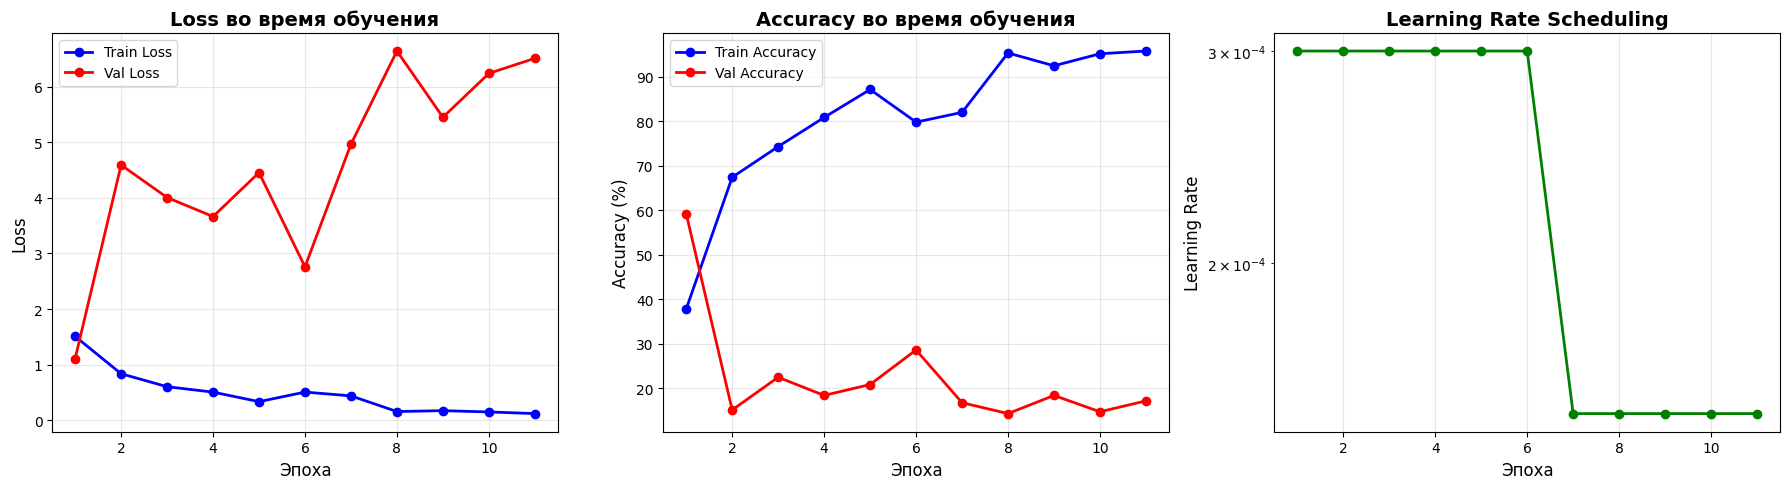

💾 График сохранен: training_history.png


In [18]:
def plot_training_history(history):
    """
    Визуализация истории обучения

    Args:
        history: словарь с метриками обучения
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    epochs = range(1, len(history['train_loss']) + 1)

    # === График Loss ===
    axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train Loss', linewidth=2)
    axes[0].plot(epochs, history['val_loss'], 'r-o', label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Эпоха', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Loss во время обучения', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)

    # === График Accuracy ===
    axes[1].plot(epochs, history['train_acc'], 'b-o', label='Train Accuracy', linewidth=2)
    axes[1].plot(epochs, history['val_acc'], 'r-o', label='Val Accuracy', linewidth=2)
    axes[1].set_xlabel('Эпоха', fontsize=12)
    axes[1].set_ylabel('Accuracy (%)', fontsize=12)
    axes[1].set_title('Accuracy во время обучения', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)

    # === График Learning Rate ===
    axes[2].plot(epochs, history['lr'], 'g-o', linewidth=2)
    axes[2].set_xlabel('Эпоха', fontsize=12)
    axes[2].set_ylabel('Learning Rate', fontsize=12)
    axes[2].set_title('Learning Rate Scheduling', fontsize=14, fontweight='bold')
    axes[2].set_yscale('log')  # Логарифмическая шкала для LR
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("💾 График сохранен: training_history.png")

# Визуализируем историю обучения
plot_training_history(history)

## 🧪 Оценка на тестовой выборке

In [19]:
# Загружаем лучшую модель
print("📥 Загрузка лучшей модели...")
checkpoint = torch.load(config.SAVE_MODEL_PATH)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"✅ Модель загружена (эпоха {checkpoint['epoch'] + 1}, val_acc: {checkpoint['val_acc']:.2f}%)")

# Тестирование
print("\n🧪 Тестирование на тестовой выборке...")
test_loss, test_acc, test_preds, test_labels = validate(
    model, test_loader, criterion, device
)

print(f"\n🎯 Результаты на тестовой выборке:")
print(f"  📊 Test Loss: {test_loss:.4f}")
print(f"  ✅ Test Accuracy: {test_acc:.2f}%")

📥 Загрузка лучшей модели...
✅ Модель загружена (эпоха 1, val_acc: 59.18%)

🧪 Тестирование на тестовой выборке...


Validation:   0%|          | 0/16 [00:00<?, ?it/s]


🎯 Результаты на тестовой выборке:
  📊 Test Loss: 1.1228
  ✅ Test Accuracy: 55.47%


## 📊 Confusion Matrix и Classification Report

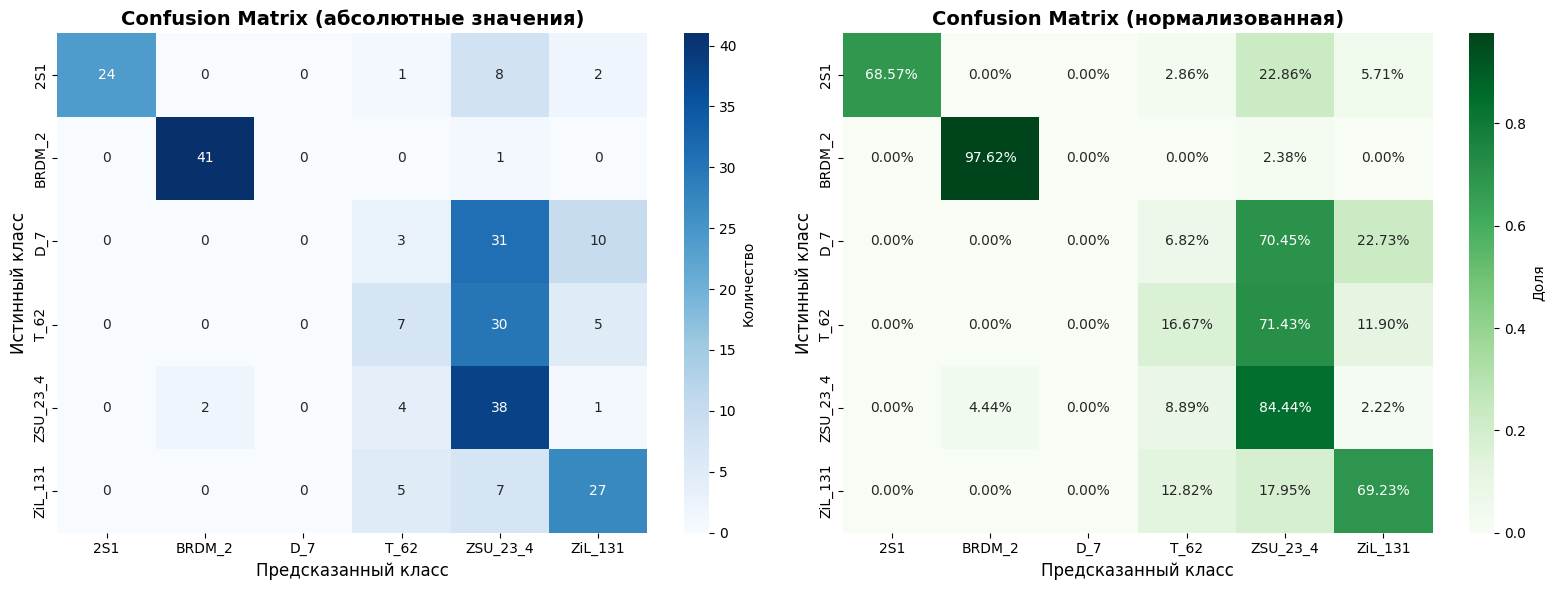

💾 Confusion matrix сохранена: confusion_matrix.png


In [20]:
def plot_confusion_matrix(y_true, y_pred, class_names):
    """
    Визуализация матрицы ошибок (confusion matrix)

    Args:
        y_true: истинные метки
        y_pred: предсказанные метки
        class_names: названия классов
    """
    # Вычисляем confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Нормализация (показываем проценты)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Создаем фигуру
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # === Абсолютные значения ===
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axes[0],
        cbar_kws={'label': 'Количество'}
    )
    axes[0].set_xlabel('Предсказанный класс', fontsize=12)
    axes[0].set_ylabel('Истинный класс', fontsize=12)
    axes[0].set_title('Confusion Matrix (абсолютные значения)', fontsize=14, fontweight='bold')

    # === Нормализованные значения (проценты) ===
    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt='.2%',
        cmap='Greens',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axes[1],
        cbar_kws={'label': 'Доля'}
    )
    axes[1].set_xlabel('Предсказанный класс', fontsize=12)
    axes[1].set_ylabel('Истинный класс', fontsize=12)
    axes[1].set_title('Confusion Matrix (нормализованная)', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("💾 Confusion matrix сохранена: confusion_matrix.png")

# Строим confusion matrix
class_names = [idx_to_class[i] for i in range(config.NUM_CLASSES)]
plot_confusion_matrix(test_labels, test_preds, class_names)

In [21]:
# Classification Report (precision, recall, f1-score для каждого класса)
print("\n📋 Classification Report:")
print("=" * 80)
print(classification_report(
    test_labels,
    test_preds,
    target_names=class_names,
    digits=4
))


📋 Classification Report:
              precision    recall  f1-score   support

         2S1     1.0000    0.6857    0.8136        35
      BRDM_2     0.9535    0.9762    0.9647        42
         D_7     0.0000    0.0000    0.0000        44
        T_62     0.3500    0.1667    0.2258        42
    ZSU_23_4     0.3304    0.8444    0.4750        45
     ZiL_131     0.6000    0.6923    0.6429        39

    accuracy                         0.5547       247
   macro avg     0.5390    0.5609    0.5203       247
weighted avg     0.5183    0.5547    0.5058       247



## 🔍 Визуализация Attention Maps

🔍 Визуализация attention для изображения класса: BRDM_2


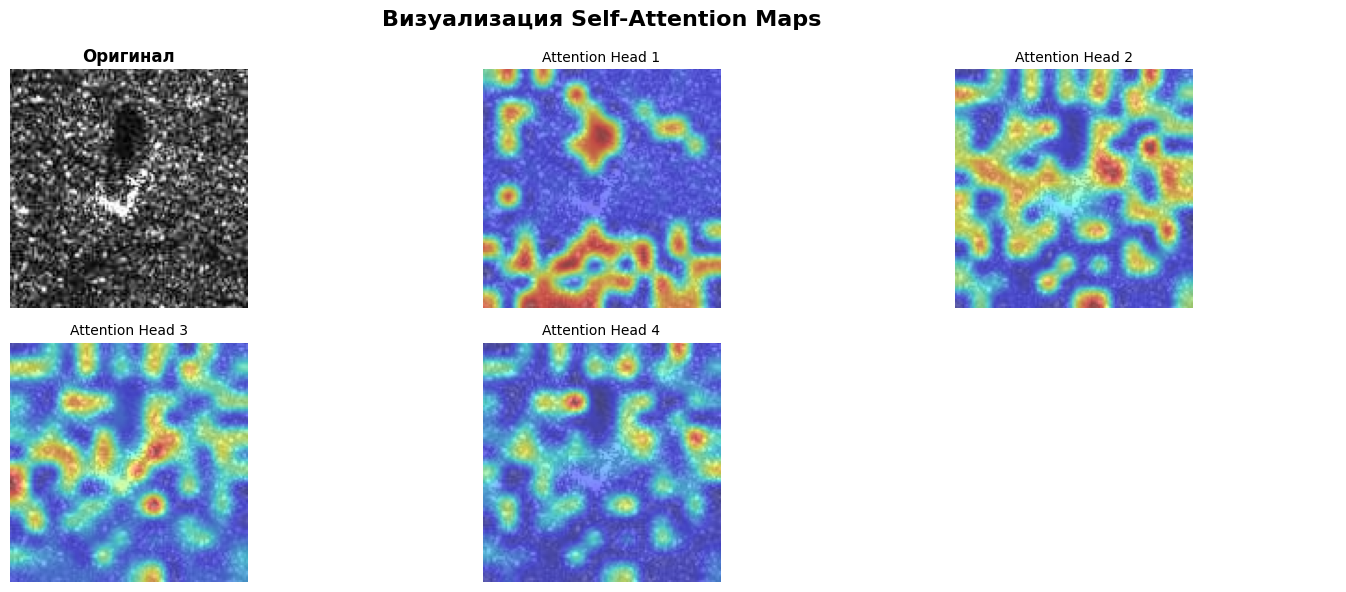

💾 Attention maps сохранены: attention_maps.png


In [22]:
def visualize_attention(model, image_tensor, original_image, device, num_heads=4):
    """
    Визуализация attention maps из Vision Transformer

    Args:
        model: обученная модель
        image_tensor: тензор изображения (preprocessed)
        original_image: оригинальное изображение (PIL)
        device: устройство
        num_heads: количество attention heads для показа
    """
    model.eval()

    # Добавляем batch dimension
    image_tensor = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        # Forward pass с получением attention weights
        outputs = model(pixel_values=image_tensor, output_attentions=True)

        # Берем attention weights последнего слоя Transformer
        # attentions имеет форму: (batch, num_heads, seq_len, seq_len)
        attentions = outputs.attentions[-1]  # Последний слой

        # Берем первый элемент батча
        attentions = attentions[0]  # (num_heads, seq_len, seq_len)

    # Переводим на CPU
    cls_attention = attentions[:, 0, 1:]  # (num_heads, num_patches)

    # Количество патчей по каждой стороне
    # ViT-base-patch16-224: 224/16 = 14 патчей по каждой стороне
    num_patches_side = int(np.sqrt(cls_attention.shape[1]))

    # Создаем фигуру
    fig, axes = plt.subplots(2, num_heads // 2 + 1, figsize=(15, 6))
    axes = axes.flatten()

    # Показываем оригинальное изображение
    axes[0].imshow(original_image)
    axes[0].set_title('Оригинал', fontsize=12, fontweight='bold')
    axes[0].axis('off')

    # Показываем attention maps для разных голов
    for i in range(min(num_heads, cls_attention.shape[0])):
        # Reshape attention в 2D карту
        attention_map = cls_attention[i].reshape(num_patches_side, num_patches_side)

        # Convert to numpy array before creating PIL Image
        attention_map_numpy = attention_map.cpu().numpy()

        # Resize до размера оригинального изображения
        attention_map_resized = np.array(
            Image.fromarray(attention_map_numpy).resize(
                original_image.size,
                resample=Image.BICUBIC
            )
        )

        # Показываем attention map поверх оригинального изображения
        axes[i + 1].imshow(original_image, alpha=0.5)
        axes[i + 1].imshow(attention_map_resized, cmap='jet', alpha=0.5)
        axes[i + 1].set_title(f'Attention Head {i + 1}', fontsize=10)
        axes[i + 1].axis('off')

    # Убираем лишние subplot'ы
    for i in range(num_heads + 1, len(axes)):
        axes[i].axis('off')

    plt.suptitle('Визуализация Self-Attention Maps', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('attention_maps.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("💾 Attention maps сохранены: attention_maps.png")

# Получаем случайное изображение из тестовой выборки
random_idx = random.randint(0, len(test_dataset) - 1)

# Получаем оригинальное изображение (до трансформаций)
original_path = test_dataset.subset.dataset.samples[test_dataset.subset.indices[random_idx]][0]
original_image = Image.open(original_path).convert('RGB')

# Получаем preprocessed изображение
preprocessed_image, label = test_dataset[random_idx]

print(f"🔍 Визуализация attention для изображения класса: {idx_to_class[label]}")
visualize_attention(model, preprocessed_image, original_image, device, num_heads=4)

## 🎯 Inference на новых изображениях

🎯 Пример inference на тестовом изображении:

📁 Путь к изображению: /content/drive/MyDrive/dataset_nik/ZiL_131/104.JPG
✅ Истинный класс: ZiL_131
🎯 Предсказанный класс: ZiL_131
📊 Уверенность: 49.50%



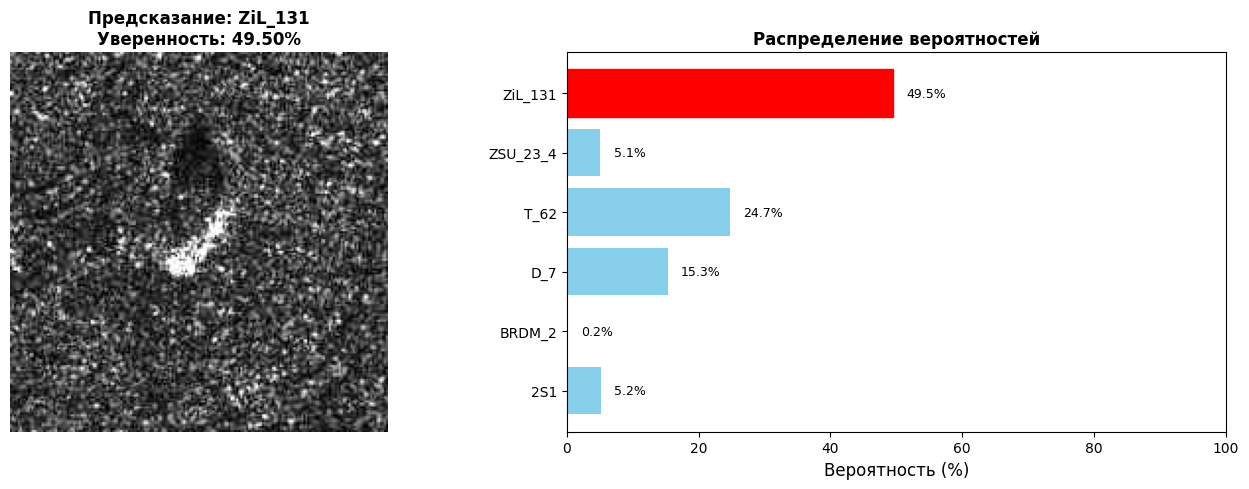

In [23]:
def predict_image(model, image_path, transform, device, class_names):
    """
    Предсказание класса для одного изображения

    Args:
        model: обученная модель
        image_path: путь к изображению
        transform: трансформации для изображения
        device: устройство
        class_names: список названий классов

    Returns:
        predicted_class: предсказанный класс
        confidence: уверенность модели
        all_probs: вероятности для всех классов
    """
    model.eval()

    # Загружаем изображение
    image = Image.open(image_path).convert('RGB')

    # Применяем трансформации
    image_tensor = transform(image).unsqueeze(0).to(device)

    # Предсказание
    with torch.no_grad():
        outputs = model(pixel_values=image_tensor)
        logits = outputs.logits

        # Применяем softmax для получения вероятностей
        probs = torch.nn.functional.softmax(logits, dim=1)

        # Получаем предсказанный класс и уверенность
        confidence, predicted = torch.max(probs, 1)

    predicted_class = class_names[predicted.item()]
    confidence = confidence.item() * 100
    all_probs = probs[0].cpu().numpy() * 100

    return predicted_class, confidence, all_probs, image


def visualize_prediction(image, predicted_class, confidence, all_probs, class_names):
    """
    Визуализация предсказания

    Args:
        image: изображение (PIL)
        predicted_class: предсказанный класс
        confidence: уверенность
        all_probs: вероятности всех классов
        class_names: названия классов
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # === Изображение ===
    axes[0].imshow(image)
    axes[0].set_title(
        f'Предсказание: {predicted_class}\nУверенность: {confidence:.2f}%',
        fontsize=12,
        fontweight='bold'
    )
    axes[0].axis('off')

    # === Bar plot с вероятностями всех классов ===
    y_pos = np.arange(len(class_names))
    bars = axes[1].barh(y_pos, all_probs, color='skyblue')

    # Выделяем предсказанный класс красным
    predicted_idx = class_names.index(predicted_class)
    bars[predicted_idx].set_color('red')

    axes[1].set_yticks(y_pos)
    axes[1].set_yticklabels(class_names)
    axes[1].set_xlabel('Вероятность (%)', fontsize=12)
    axes[1].set_title('Распределение вероятностей', fontsize=12, fontweight='bold')
    axes[1].set_xlim(0, 100)

    # Добавляем значения на баре
    for i, (bar, prob) in enumerate(zip(bars, all_probs)):
        axes[1].text(
            prob + 2, i, f'{prob:.1f}%',
            va='center', fontsize=9
        )

    plt.tight_layout()
    plt.show()


# Пример: предсказание на случайном изображении из тестовой выборки
print("🎯 Пример inference на тестовом изображении:\n")

# Берем случайное изображение
random_idx = random.randint(0, len(test_dataset) - 1)
image_path = test_dataset.subset.dataset.samples[test_dataset.subset.indices[random_idx]][0]
true_label = test_dataset.subset.dataset.samples[test_dataset.subset.indices[random_idx]][1]

# Предсказание
predicted_class, confidence, all_probs, image = predict_image(
    model, image_path, val_test_transforms, device, class_names
)

print(f"📁 Путь к изображению: {image_path}")
print(f"✅ Истинный класс: {idx_to_class[true_label]}")
print(f"🎯 Предсказанный класс: {predicted_class}")
print(f"📊 Уверенность: {confidence:.2f}%\n")

# Визуализация
visualize_prediction(image, predicted_class, confidence, all_probs, class_names)

## 💾 Сохранение модели для продакшена

In [24]:
# Сохранение полной модели (для легкой загрузки)
final_model_path = '/content/vit_radar_classifier_final.pth'

torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': class_names,
    'idx_to_class': idx_to_class,
    'config': {
        'num_classes': config.NUM_CLASSES,
        'image_size': config.IMAGE_SIZE,
        'model_name': config.MODEL_NAME
    },
    'test_accuracy': test_acc,
    'history': history
}, final_model_path)

print(f"✅ Финальная модель сохранена: {final_model_path}")
print(f"📊 Test Accuracy: {test_acc:.2f}%")

# Инструкция по загрузке модели
print("\n📖 Инструкция по загрузке модели:")
print("""
# Загрузка модели
checkpoint = torch.load('vit_radar_classifier_final.pth')

# Создание модели
from transformers import ViTForImageClassification
model = ViTForImageClassification.from_pretrained(
    checkpoint['config']['model_name'],
    num_labels=checkpoint['config']['num_classes']
)

# Загрузка весов
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Использование
class_names = checkpoint['class_names']
""")

✅ Финальная модель сохранена: /content/vit_radar_classifier_final.pth
📊 Test Accuracy: 55.47%

📖 Инструкция по загрузке модели:

# Загрузка модели
checkpoint = torch.load('vit_radar_classifier_final.pth')

# Создание модели
from transformers import ViTForImageClassification
model = ViTForImageClassification.from_pretrained(
    checkpoint['config']['model_name'],
    num_labels=checkpoint['config']['num_classes']
)

# Загрузка весов
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Использование
class_names = checkpoint['class_names']



## 📊 Итоговая статистика

In [25]:
print("\n" + "=" * 80)
print("📊 ИТОГОВАЯ СТАТИСТИКА")
print("=" * 80)

print(f"\n🎯 Датасет:")
print(f"  📂 Классов: {config.NUM_CLASSES}")
print(f"  🖼️  Всего изображений: {len(full_dataset)}")
print(f"  🎯 Train: {len(train_dataset)} изображений")
print(f"  ✅ Validation: {len(val_dataset)} изображений")
print(f"  🧪 Test: {len(test_dataset)} изображений")

print(f"\n🏗️ Модель:")
print(f"  🤖 Архитектура: Vision Transformer (ViT)")
print(f"  📦 Предобученная модель: {config.MODEL_NAME}")
print(f"  🔢 Параметров: {total_params:,}")
print(f"  💾 Размер: ~{total_params * 4 / 1024 / 1024:.2f} MB")

print(f"\n📈 Результаты обучения:")
print(f"  🏆 Лучшая Val Accuracy: {best_val_acc:.2f}%")
print(f"  🧪 Test Accuracy: {test_acc:.2f}%")
print(f"  📉 Test Loss: {test_loss:.4f}")
print(f"  🔄 Обучено эпох: {len(history['train_loss'])}")

print(f"\n💾 Сохраненные файлы:")
print(f"  📁 {config.SAVE_MODEL_PATH} - лучшая модель")
print(f"  📁 {final_model_path} - финальная модель")
print(f"  📊 training_history.png - графики обучения")
print(f"  📊 confusion_matrix.png - матрица ошибок")
print(f"  🔍 attention_maps.png - визуализация attention")

print("\n" + "=" * 80)
print("✅ ВСЕ ГОТОВО! Модель успешно обучена!")
print("=" * 80)


📊 ИТОГОВАЯ СТАТИСТИКА

🎯 Датасет:
  📂 Классов: 6
  🖼️  Всего изображений: 1638
  🎯 Train: 1146 изображений
  ✅ Validation: 245 изображений
  🧪 Test: 247 изображений

🏗️ Модель:
  🤖 Архитектура: Vision Transformer (ViT)
  📦 Предобученная модель: google/vit-base-patch16-224
  🔢 Параметров: 85,803,270
  💾 Размер: ~327.31 MB

📈 Результаты обучения:
  🏆 Лучшая Val Accuracy: 59.18%
  🧪 Test Accuracy: 55.47%
  📉 Test Loss: 1.1228
  🔄 Обучено эпох: 11

💾 Сохраненные файлы:
  📁 /content/best_model.pth - лучшая модель
  📁 /content/vit_radar_classifier_final.pth - финальная модель
  📊 training_history.png - графики обучения
  📊 confusion_matrix.png - матрица ошибок
  🔍 attention_maps.png - визуализация attention

✅ ВСЕ ГОТОВО! Модель успешно обучена!
